# IMDB Movie Review Sentiment Analysis
### Tokenization, Logistic Regression, Random Forest, and Model Comparison

This project uses the IMDB movie review dataset to predict whether a review is **positive** or **negative**.

The main goal is to turn text into numerical features, train two machine learning models, and compare which model performs better.

## 1. Import Libraries

These libraries help us load data, clean text, tokenize reviews, create visuals, and build the models.

In [ ]:
# Import all libraries

import os
import re
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

## 2. Load the Dataset

Make sure the CSV file is uploaded into the same folder as this notebook.

Expected file name: **IMDB-Dataset.csv**

In [ ]:
possible_files = [
    'IMDB-Dataset.csv',
    '/content/IMDB-Dataset.csv',
    '/tmp/IMDB-Dataset.csv'
]
data_file = None
for file in possible_files:
    if os.path.exists(file):
        data_file = file
        break

if data_file is None:
    raise FileNotFoundError('Please upload IMDB-Dataset.csv into the notebook folder.')

# Import data into dataframe
df = pd.read_csv(data_file, on_bad_lines='skip', engine='python')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
import os
import pandas as pd

possible_files = [
    'IMDB-Dataset.csv',
    '/content/IMDB-Dataset.csv',
    '/tmp/IMDB-Dataset.csv'
]
data_file = None
for file in possible_files:
    if os.path.exists(file):
        data_file = file
        break

if data_file is None:
    raise FileNotFoundError('Please upload IMDB-Dataset.csv into the notebook folder.')

# Import data into dataframe
df = pd.read_csv(data_file, on_bad_lines='skip', engine='python')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
# Create 150 TF-IDF word/token columns and add them to the dataframe

from sklearn.feature_extraction.text import TfidfVectorizer
import re # Ensure 're' is imported for clean_text

# Create a text cleaning function
# remove HTML tags like <br />
# remove links
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r"'", '', text)
    text = re.sub(r"[^a-z'\s]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Ensure 'clean_review' exists in the main dataframe
df['clean_review'] = df['review'].apply(clean_text)

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
custom_stop_words = list(ENGLISH_STOP_WORDS) + ['s', 't', 'br', 've', 'll', 're']

# Create TF-IDF vectorizer with 150 word features
tfidf_100 = TfidfVectorizer(
    max_features=150,
    stop_words=custom_stop_words
)

# Fit and transform the cleaned review text
X_tfidf_100 = tfidf_100.fit_transform(df['clean_review'])

# Convert TF-IDF matrix into a dataframe
tfidf_100_df = pd.DataFrame(
    X_tfidf_100.toarray(),
    columns=tfidf_100.get_feature_names_out()
)

# Add a prefix so the new columns are easy to recognize
tfidf_100_df.columns = ['tfidf_' + col for col in tfidf_100_df.columns]

# Combine original dataframe with the 150 TF-IDF columns
df = pd.concat(
    [df.reset_index(drop=True), tfidf_100_df.reset_index(drop=True)],
    axis=1
)

# View the updated dataframe
df.head()

,review,sentiment,clean_review,tfidf_acting,tfidf_action,tfidf_actor,tfidf_actors,tfidf_actually,tfidf_american,tfidf_audience,...,tfidf_watching,tfidf_way,tfidf_woman,tfidf_work,tfidf_world,tfidf_worst,tfidf_worth,tfidf_year,tfidf_years,tfidf_young
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.326928,0.000000,0.000000,0.00000,0.00000,0.0,0.000000,0.0,0.000000,0.000000
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,0.000000,0.000000,0.0,0.225947,0.0,0.0,0.0,...,0.224551,0.000000,0.000000,0.00000,0.00000,0.0,0.267816,0.0,0.000000,0.000000
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.198361,0.168150,0.244434,0.00000,0.00000,0.0,0.000000,0.0,0.201839,0.223876
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.00000,0.0,0.000000,0.0,0.000000,0.000000
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,0.115836,0.154254,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.111711,0.000000,0.13673,0.14733,0.0,0.000000,0.0,0.000000,0.000000


In [ ]:
# Show dataframe size
print(df.shape)

(22912, 153)


In [ ]:
# Basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22912 entries, 0 to 22911
Columns: 153 entries, review to tfidf_young
dtypes: float64(150), object(3)
memory usage: 26.7+ MB


In [ ]:
# Describe categorical columns
df.describe(include='object')

,review,sentiment,clean_review
count,22912,22912,22912
unique,22820,2,22820
top,Loved today's show!!! It was a variety and not...,negative,loved todays show it was a variety and not sol...
freq,4,11518,4


## 3. Check for Missing Values and Duplicates

Before modeling, we check whether the data has missing values or duplicate rows.

In [ ]:
# Check missing values
df.isnull().sum()

,0
review,0
sentiment,0
clean_review,0
tfidf_acting,0
tfidf_action,0
...,...
tfidf_worst,0
tfidf_worth,0
tfidf_year,0
tfidf_years,0


In [ ]:
# Check duplicate rows
duplicates = df.duplicated()

print(duplicates.sum())

92


In [ ]:
# Remove duplicate rows
# This keeps the first version of each duplicated review.
df = df.drop_duplicates().copy()

print('Shape after removing duplicates:', df.shape)

Shape after removing duplicates: (22820, 153)


## 4. Encode the Target Variable

The original sentiment column is text:

- positive
- negative

For machine learning, we convert it into numbers:

- positive = 1
- negative = 0

In [ ]:
# Map sentiment into numbers
df['sentiment_numeric'] = df['sentiment'].map({'negative': 0, 'positive': 1})

# Show new column
display(df[['sentiment', 'sentiment_numeric']].head())

,sentiment,sentiment_numeric
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


In [ ]:
# Check target balance
df['sentiment'].value_counts()

,count
sentiment,
negative,11453
positive,11367


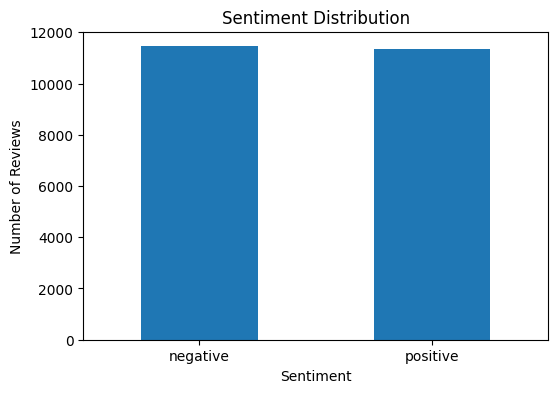

In [ ]:
# Visualize sentiment distribution
plt.figure(figsize=(6, 4))
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

## Create a Working Sample

The full dataset has almost 50,000 reviews. To keep the project easy to run, the rest of the notebook uses a random sample of 5,000 reviews.

This is especially helpful because Random Forest can be slow with text data.

In [ ]:
# Working sample
ANALYSIS_SIZE = 5000

df_analysis = df.sample(n=min(ANALYSIS_SIZE, len(df)), random_state=42).copy()

print('Working dataframe shape:', df_analysis.shape)
print(df_analysis['sentiment'].value_counts())

Working dataframe shape: (5000, 154)
sentiment
negative    2563
positive    2437
Name: count, dtype: int64


## 5. Clean the Review Text

Text data usually has extra characters that do not help the model.

Here we remove HTML tags, punctuation, numbers, and extra spaces. We also convert everything to lowercase.

In [ ]:
# Create a text cleaning function

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r"[^a-z'\s]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
# Apply text cleaning
df_analysis['clean_review'] = df_analysis['review'].apply(clean_text)

# Compare original and cleaned text
display(df_analysis[['review', 'clean_review']].head())

,review,clean_review
12418,"I have not seen such a stupid,dumb movie since...",i have not seen such a stupid dumb movie since...
18609,This show has a few clichés and a few over the...,this show has a few clich s and a few over the...
4005,The Movie I thought was excellent it was suppo...,the movie i thought was excellent it was suppo...
3184,---what happened to these unlikeable people. A...,what happened to these unlikeable people alan ...
283,I am not so old that I can't remember laughing...,i am not so old that i can't remember laughing...


## 6. Tokenization

Tokenization: splitting text into individual words/tokens.

Example:  
`"this movie was great"` becomes `["this", "movie", "was", "great"]`.

In [ ]:
# Tokenize the cleaned reviews using split()
df_analysis['tokens'] = df_analysis['clean_review'].apply(lambda x: x.split())

# Count the number of tokens and characters in each review
df_analysis['token_count'] = df_analysis['tokens'].apply(len)
df_analysis['review_length'] = df_analysis['clean_review'].apply(len)

# Show tokenization results
display(df_analysis[['clean_review', 'tokens', 'token_count', 'review_length']].head())

,clean_review,tokens,token_count,review_length
12418,i have not seen such a stupid dumb movie since...,"[i, have, not, seen, such, a, stupid, dumb, mo...",141,712
18609,this show has a few clich s and a few over the...,"[this, show, has, a, few, clich, s, and, a, fe...",127,631
4005,the movie i thought was excellent it was suppo...,"[the, movie, i, thought, was, excellent, it, w...",123,598
3184,what happened to these unlikeable people alan ...,"[what, happened, to, these, unlikeable, people...",85,441
283,i am not so old that i can't remember laughing...,"[i, am, not, so, old, that, i, can't, remember...",172,902


In [ ]:
# Average token count by sentiment
df_analysis.groupby('sentiment')['token_count'].mean()

,token_count
sentiment,
negative,225.242684
positive,235.256463


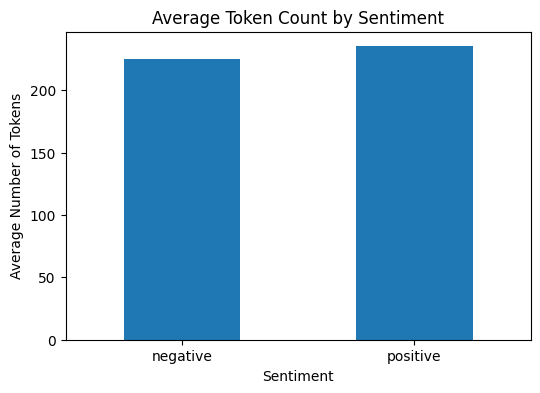

In [ ]:
# Visualize average token count by sentiment
avg_tokens = df_analysis.groupby('sentiment')['token_count'].mean()

plt.figure(figsize=(6, 4))
avg_tokens.plot(kind='bar')
plt.title('Average Token Count by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Number of Tokens')
plt.xticks(rotation=0)
plt.show()

## 7. Most Common Tokens

This gives us a simple look at the words that appear most often after cleaning.

Common English stop words like "the" and "and" are removed to make the list more useful.

In [ ]:
# Use a smaller sample for token exploration to keep the notebook fast
sample_for_tokens = df_analysis.copy()

all_tokens = sample_for_tokens['tokens'].explode()
all_tokens = all_tokens[~all_tokens.isin(ENGLISH_STOP_WORDS)]

common_tokens = all_tokens.value_counts().head(20)
common_tokens

,count
tokens,
movie,8868
film,7725
like,4157
just,3553
it's,3356
good,2995
time,2598
story,2294
really,2256


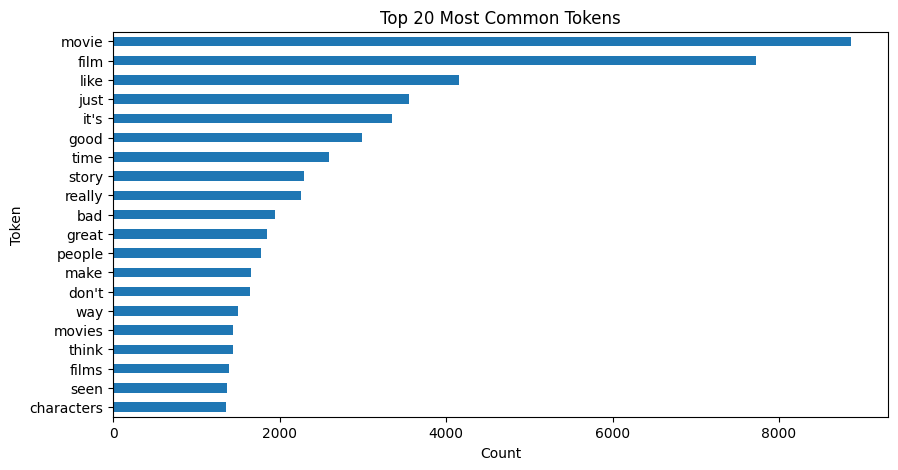

In [ ]:
# Plot top 20 most common tokens
plt.figure(figsize=(10, 5))
common_tokens.sort_values().plot(kind='barh')
plt.title('Top 20 Most Common Tokens')
plt.xlabel('Count')
plt.ylabel('Token')
plt.show()

## 8. Prepare Data for Modeling

Random Forest can run slowly on large text datasets, so this notebook uses a sample of 5,000 reviews.

The modeling section uses the working sample created above.

In [ ]:
# Choose sample size for modeling
SAMPLE_SIZE = 5000

if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df_analysis):
    df_model = df_analysis.sample(n=SAMPLE_SIZE, random_state=42).copy()
else:
    df_model = df_analysis.copy()

print('Modeling dataframe shape:', df_model.shape)
print(df_model['sentiment'].value_counts())

Modeling dataframe shape: (5000, 157)
sentiment
negative    2563
positive    2437
Name: count, dtype: int64


In [ ]:
# Define X and y
X = df_model['clean_review']
y = df_model['sentiment_numeric']

# Split dataset into training and test set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (4000,)
X_test shape: (1000,)
y_train shape: (4000,)
y_test shape: (1000,)


## 9. Convert Text into Numbers with TF-IDF

Models cannot read words directly. TF-IDF converts text into a numerical matrix.

TF-IDF gives higher importance to words that are useful in a review but not common across every review.

In [ ]:
# Convert text to numerical features
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=150,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print('Training TF-IDF shape:', X_train_tfidf.shape)
print('Testing TF-IDF shape:', X_test_tfidf.shape)

Training TF-IDF shape: (4000, 150)
Testing TF-IDF shape: (1000, 150)


In [ ]:
# Show a sample of the TF-IDF feature names
feature_names = vectorizer.get_feature_names_out()
feature_names[:25]

array(['acting', 'action', 'actors', 'actually', 'american', 'audience',
       'away', 'bad', 'beautiful', 'believe', 'best', 'better', 'big',
       'bit', 'book', 'cast', 'character', 'characters', 'come', 'comedy',
       'comes', 'course', 'day', 'did', 'didn'], dtype=object)

## 10. Logistic Regression Model

Logistic Regression is a strong baseline model for sentiment analysis because it works well with sparse text features.

In [ ]:
# Build and train Logistic Regression model
logistic_regression = LogisticRegression(max_iter=1000, random_state=42)

logistic_regression.fit(X_train_tfidf, y_train)

# Make predictions
y_pred_log = logistic_regression.predict(X_test_tfidf)
y_proba_log = logistic_regression.predict_proba(X_test_tfidf)[:, 1]

In [ ]:
# Logistic Regression evaluation
print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_log))
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_log, target_names=['Negative', 'Positive']))

Logistic Regression Accuracy: 0.719

Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.71      0.72       513
    Positive       0.71      0.73      0.72       487

    accuracy                           0.72      1000
   macro avg       0.72      0.72      0.72      1000
weighted avg       0.72      0.72      0.72      1000



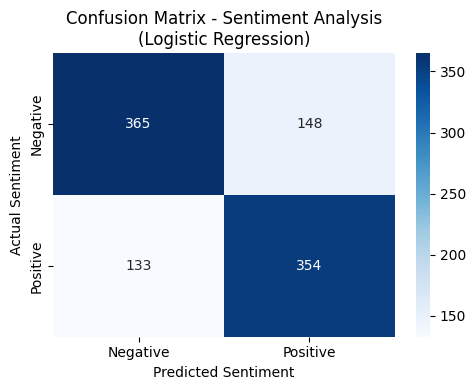

In [ ]:
# Confusion Matrix: Sentiment Analysis (Logistic Regression)
cm_log = confusion_matrix(y_test, y_pred_log)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            ax=ax)
ax.set_xlabel('Predicted Sentiment')
ax.set_ylabel('Actual Sentiment')
ax.set_title('Confusion Matrix - Sentiment Analysis\n(Logistic Regression)')
plt.tight_layout()
plt.show()

## 11. Random Forest Model


In [ ]:
# Build and train Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train_tfidf, y_train)

# Make predictions
y_pred_rf = random_forest.predict(X_test_tfidf)
y_proba_rf = random_forest.predict_proba(X_test_tfidf)[:, 1]

In [ ]:
# Random Forest evaluation
print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Negative', 'Positive']))

Random Forest Accuracy: 0.702

Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.70      0.71       513
    Positive       0.69      0.71      0.70       487

    accuracy                           0.70      1000
   macro avg       0.70      0.70      0.70      1000
weighted avg       0.70      0.70      0.70      1000



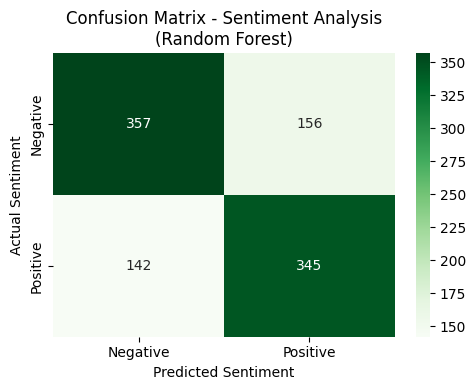

In [ ]:
# Confusion Matrix - Sentiment Analysis (Random Forest)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            ax=ax)
ax.set_xlabel('Predicted Sentiment')
ax.set_ylabel('Actual Sentiment')
ax.set_title('Confusion Matrix - Sentiment Analysis\n(Random Forest)')
plt.tight_layout()
plt.show()

## 12. Model Comparison

Now we compare Logistic Regression and Random Forest using the same test set.

Metrics:

- Accuracy: overall percentage correct
- Precision: how many predicted positives were truly positive
- Recall: how many actual positives were found
- F1-score: balance between precision and recall
- ROC AUC: how well the model separates positive and negative reviews

In [ ]:
# Store model results in a dataframe
results = []

results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_log),
    'Precision': precision_score(y_test, y_pred_log),
    'Recall': recall_score(y_test, y_pred_log),
    'F1-score': f1_score(y_test, y_pred_log),
    'ROC AUC': roc_auc_score(y_test, y_proba_log)
})

results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-score': f1_score(y_test, y_pred_rf),
    'ROC AUC': roc_auc_score(y_test, y_proba_rf)
})

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Logistic Regression,0.719,0.705179,0.726899,0.715875,0.809627
1,Random Forest,0.702,0.688623,0.708419,0.698381,0.782663


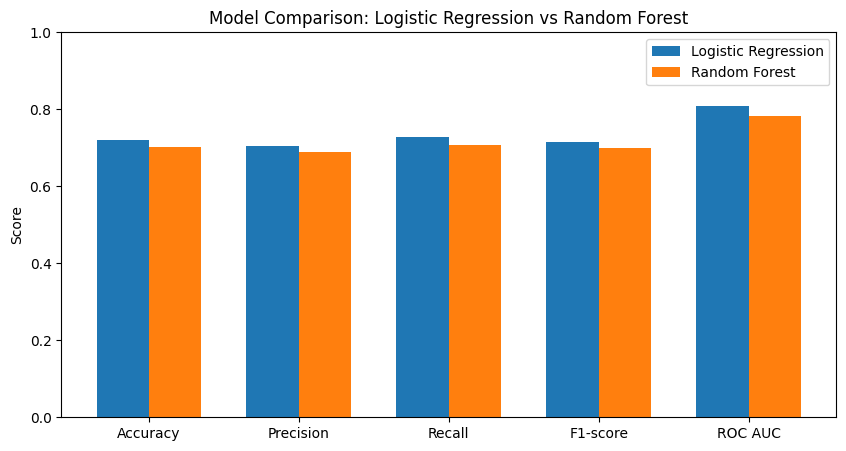

In [ ]:
# Visual comparison of model performance
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC AUC']
x = np.arange(len(metrics_to_plot))
width = 0.35

log_scores = results_df.loc[results_df['Model'] == 'Logistic Regression', metrics_to_plot].values[0]
rf_scores = results_df.loc[results_df['Model'] == 'Random Forest', metrics_to_plot].values[0]

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, log_scores, width, label='Logistic Regression')
plt.bar(x + width/2, rf_scores, width, label='Random Forest')
plt.xticks(x, metrics_to_plot)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Comparison: Logistic Regression vs Random Forest')
plt.legend()
plt.show()

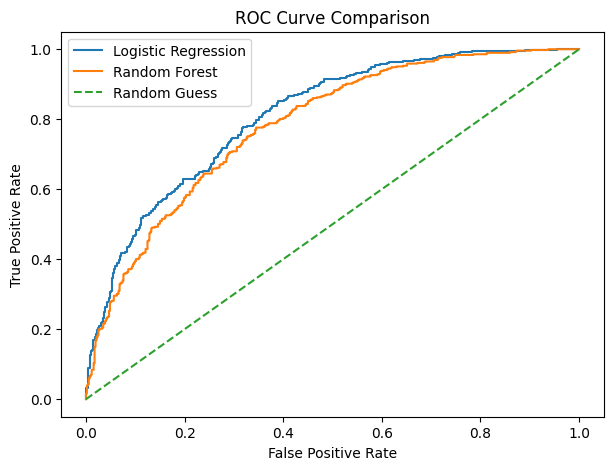

In [ ]:
# ROC Curve comparison
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [ ]:
# Identify best model by F1-score
best_model_row = results_df.sort_values(by='F1-score', ascending=False).iloc[0]

print('Best model based on F1-score:')
print(best_model_row)

Best model based on F1-score:
Model        Logistic Regression
Accuracy                   0.719
Precision               0.705179
Recall                  0.726899
F1-score                0.715875
ROC AUC                 0.809627
Name: 0, dtype: object


## 13. Interpreting the Models

Logistic Regression gives coefficients for words and phrases.

Positive coefficients are connected to positive sentiment.

Negative coefficients are connected to negative sentiment.

Random Forest gives feature importance scores, which show which words/phrases helped the trees make predictions.

In [ ]:
# Logistic Regression important words
coefficients = logistic_regression.coef_[0]
feature_names = vectorizer.get_feature_names_out()

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

positive_words = coef_df.sort_values(by='Coefficient', ascending=False).head(15)
negative_words = coef_df.sort_values(by='Coefficient', ascending=True).head(15)

print('Top Positive Words/Phrases')
display(positive_words)

print('Top Negative Words/Phrases')
display(negative_words)

Top Positive Words/Phrases


,Feature,Coefficient
49,great,3.330720
10,best,2.663268
8,beautiful,2.320335
57,job,2.183888
13,bit,2.067618
25,different,2.048639
74,love,1.980057
129,true,1.610171
104,right,1.589639
34,especially,1.554734


Top Negative Words/Phrases


,Feature,Coefficient
145,worst,-5.562474
7,bad,-4.537591
82,money,-2.788042
96,plot,-2.281874
81,minutes,-2.263045
112,script,-2.242971
51,half,-2.023919
72,looks,-1.726035
11,better,-1.719455
98,pretty,-1.610843


In [ ]:
# Random Forest important words
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': random_forest.feature_importances_
})

rf_top_features = rf_importance.sort_values(by='Importance', ascending=False).head(20)
rf_top_features

,Feature,Importance
7,bad,0.053727
145,worst,0.040999
49,great,0.031999
83,movie,0.022362
10,best,0.018861
59,just,0.016934
96,plot,0.016043
74,love,0.015749
66,like,0.014617
39,film,0.012893


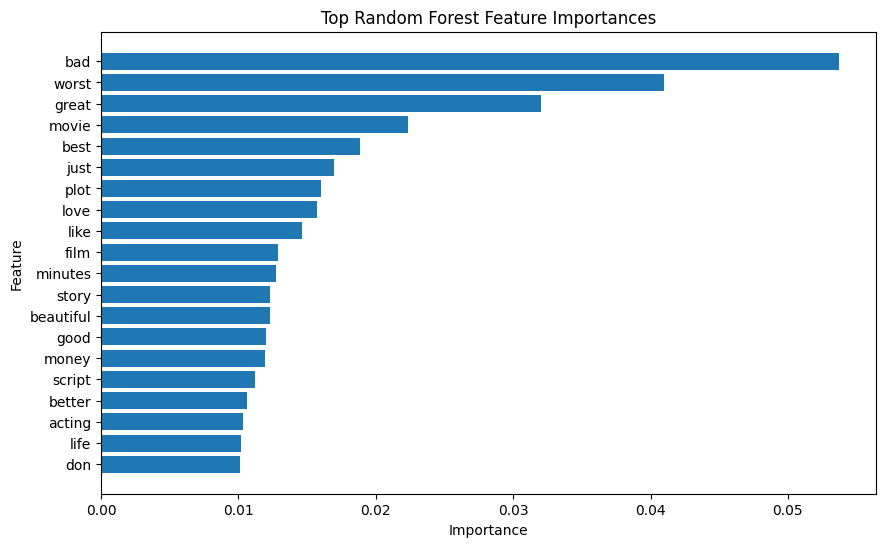

In [ ]:
# Plot Random Forest feature importance
plt.figure(figsize=(10, 6))
plt.barh(rf_top_features['Feature'][::-1], rf_top_features['Importance'][::-1])
plt.title('Top Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### 14. Test the Model on New Reviews

This final section shows how well the trained models predict sentiment for new movie reviews.

In [ ]:
# Create new example reviews
new_reviews = [
    'This movie was amazing. The acting was great and the story was powerful.',
    'This was a boring movie. The plot was weak and I would not watch it again.'
]

# Clean and vectorize the new reviews
new_reviews_clean = [clean_text(review) for review in new_reviews]
new_reviews_tfidf = vectorizer.transform(new_reviews_clean)

# Predict with both models
log_predictions = logistic_regression.predict(new_reviews_tfidf)
rf_predictions = random_forest.predict(new_reviews_tfidf)

prediction_df = pd.DataFrame({
    'Review': new_reviews,
    'Logistic Regression Prediction': ['Positive' if p == 1 else 'Negative' for p in log_predictions],
    'Random Forest Prediction': ['Positive' if p == 1 else 'Negative' for p in rf_predictions]
})

prediction_df

,Review,Logistic Regression Prediction,Random Forest Prediction
0,This movie was amazing. The acting was great a...,Positive,Positive
1,This was a boring movie. The plot was weak and...,Negative,Negative


In [ ]:
df.shape

(22820, 154)

## Conclusion

This project shows how movie review text can be converted into numerical features and used for sentiment anal.

Logistic Regression is usually easier to interpret and often performs very well with TF-IDF text data. Random Forest is useful for comparison, but it can be slower and may not always beat Logistic Regression on sparse text features.

For a business, this type of model could help summarize thousands of reviews quickly and identify whether customer feedback is mostly positive or negative.

#*Deep Learning*


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
import os
import pandas as pd

possible_files = [
    'IMDB-Dataset.csv',
    '/content/IMDB-Dataset.csv',
    '/tmp/IMDB-Dataset.csv'
]
data_file = None
for file in possible_files:
    if os.path.exists(file):
        data_file = file
        break

if data_file is None:
    raise FileNotFoundError('Please upload IMDB-Dataset.csv into the notebook folder.')

# Import data into dataframe
df = pd.read_csv(data_file, on_bad_lines='skip', engine='python')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.shape
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22912 entries, 0 to 22911
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     22912 non-null  object
 1   sentiment  22912 non-null  object
dtypes: object(2)
memory usage: 358.1+ KB


,0
review,0
sentiment,0


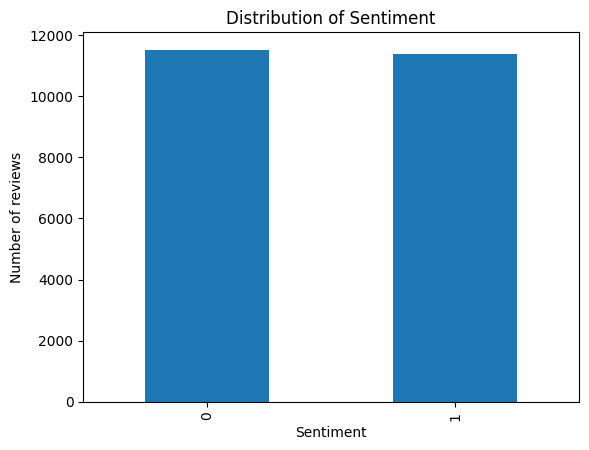

In [ ]:
df['sentiment_numeric'] = df['sentiment'].map({'negative': 0, 'positive': 1})
df["sentiment_numeric"].value_counts()
df["sentiment_numeric"].value_counts(normalize=True)
df["sentiment_numeric"].value_counts().plot(kind="bar")
plt.title("Distribution of Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of reviews")
plt.show()

In [ ]:
_train, X_test, y_train, y_test = train_test_split(
 X,
 y,
 test_size=0.2,
 random_state=42,
 stratify=y
)

Deep Learning Model Test Accuracy: 0.8731


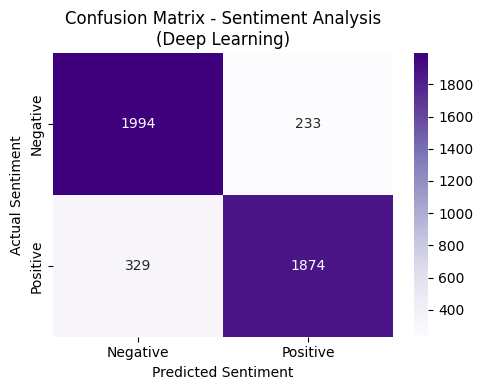

In [ ]:
print(f"Deep Learning Model Test Accuracy: {accuracy:.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            ax=ax)
ax.set_xlabel('Predicted Sentiment')
ax.set_ylabel('Actual Sentiment')
ax.set_title('Confusion Matrix - Sentiment Analysis\n(Deep Learning)')
plt.tight_layout()
plt.show()